# Seaborn

## Introducción

* ***¿Qué es Seaborn realmente?***
* Seaborn es una capa encima de matplotlib que:
  - Entiende DataFrames.
  - Maneja categorías automáticamente.
  - Tiene mejores defaults visuales.
  - Permite mapear variables a colores, tamaños, estilos.
* ***Tipos de Graficas***
* `replot` (Relacional).
  - `scatterplot` (Dispersión).
  - `lineplot` (lineal)
* `displot` (Distribuciones).
  - `histplot`.
  - `kdeplot`.
  - `ecdfplot`.
  - `rugplot`.
* `catplot` (Categóricos).
  - `stripplot`.
  - `swarmplot`.
  - `boxplot`.
  - `violinplot`.
  - `pointplot`.
  - `barplot`.

## Scatter plot

* `sns.scatterplot()`: Es el equivalente a `plt.scatter()`, pero más poderoso.
* `hue` → color por categoría.
* `hue`en matplotlib
```python
grupo_A = df[df["grupo"] == "A"]
grupo_B = df[df["grupo"] == "B"]

plt.scatter(grupo_A["x"], grupo_A["y"], label="A")
plt.scatter(grupo_B["x"], grupo_B["y"], label="B")

plt.legend()
plt.title("Scatter con Matplotlib")
plt.show()
```

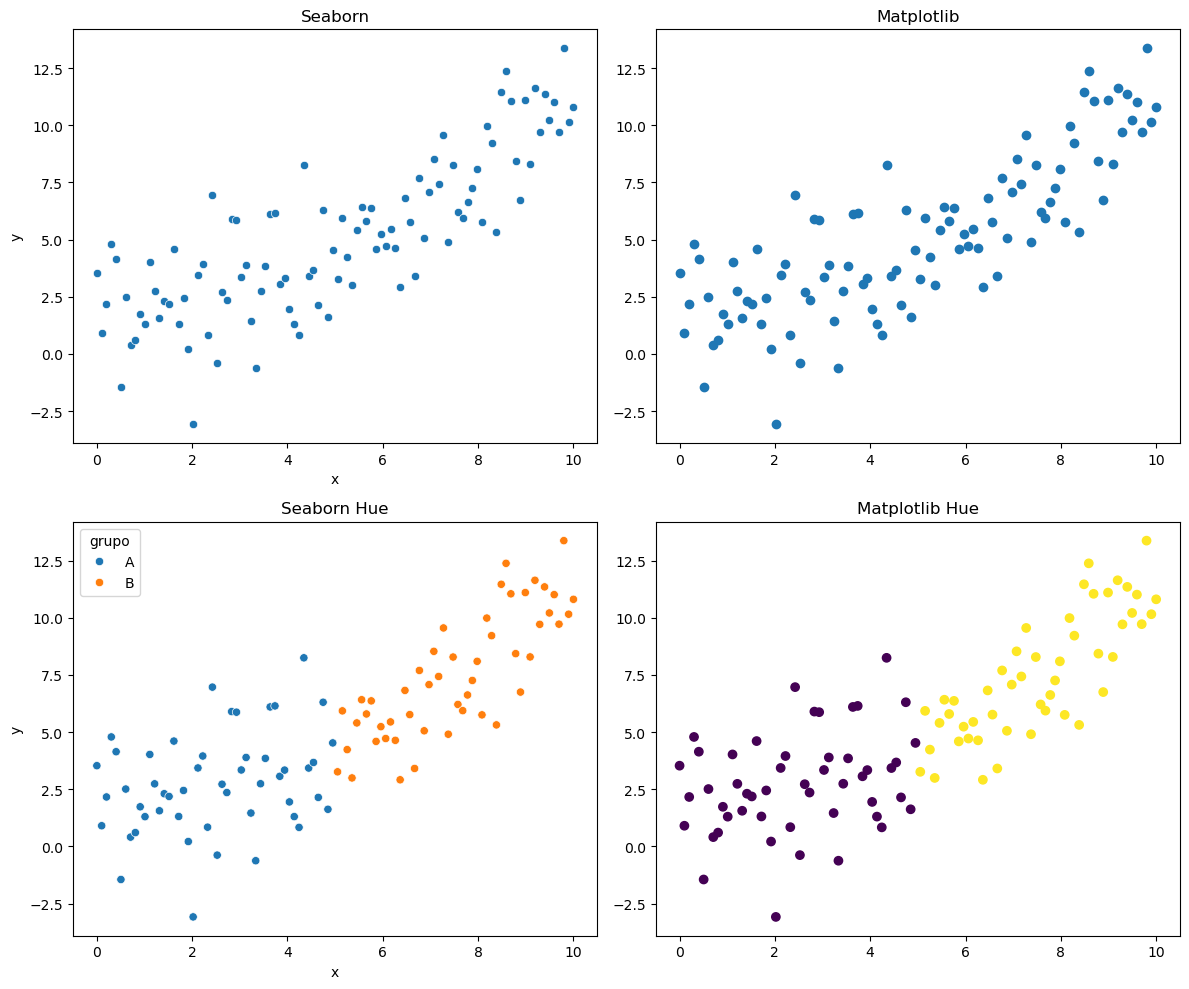

<Figure size 640x480 with 0 Axes>

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

df = pd.DataFrame({
    "x": np.linspace(0,10,100),
    "y": np.linspace(0,10,100) + np.random.normal(0,2,100)
})

fig, axes = plt.subplots(2, 2, figsize=(12,10))

# Seaborn
sns.scatterplot(data=df, x="x", y="y", ax=axes[0,0])
axes[0,0].set_title("Seaborn")

# Matplotlib
axes[0,1].scatter(df["x"], df["y"])
axes[0,1].set_title("Matplotlib")

df["grupo"] = np.where(df["x"] < 5, "A", "B")

# Seaborn con hue
sns.scatterplot(data=df, x="x", y="y", hue="grupo", ax=axes[1,0])
axes[1,0].set_title("Seaborn Hue")

# Hue con matplot
### Convertir categorías a números para que Matplotlib pueda usarlas con un colormap
df['grupo_num'] = df['grupo'].astype('category').cat.codes
axes[1,1].scatter(df["x"], df["y"], c=df["grupo_num"], cmap='viridis')
axes[1,1].set_title("Matplotlib Hue")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### size

* `np.random.randint(20, 200, size=len(df))`:
  - Genera números enteros aleatorios entre 20 y 199.
  - `size=len(df)` indica que se genera un número ***por cada fila del DataFrame***.
* `size`: tamaño de los puntos.
* `Seaborn` escala automáticamente los tamaños para que se vean bien.
* `s` en Matplotlib:
  - Representa el tamaño de los puntos directamente.
  - No hace “mapeo” automático como Seaborn.
* Es decir, `s` puede ser:
  - Un solo número → todos los puntos del mismo tamaño.
  - Un array → un tamaño por punto.
* `s` representa el área del punto, no el radio.
* Los valores suelen ser más “grandes” numéricamente que en Seaborn.
* Cada dimensión visual debe tener propósito:
  - color (`hue`).
  - tamaño (`size`).
  - forma (`style`).
* ¿Cuándo sí usar `size`?
  - Negocios: X = unverisón en marketing, Y = ventas y size = número de clientes.
  - Salud: X = edad, Y = presión arterial, size = peso.
  - ML / Clustering: X = feature 1, Y = feature 2 y size = importancia / frecuencia.

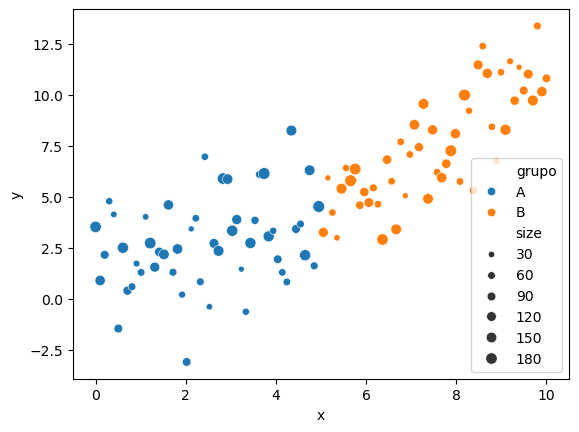

In [2]:
df["size"] = np.random.randint(20,200,size=len(df))

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="grupo",
    size="size"
)

plt.show()

### style

* `df["tipo"] = np.where(df["y"] > df["y"].mean(), "alto", "bajo")`:
  - Saca los valores que estén por encima del promedio de `y`, si está arriba `alto` caso contrario `bajo`.
* Como la media está en ***5***, todos los valores abajo tendrán un formato y los que estén arriba otro.
* `style` = variable categórica → cambia la forma del marcador.
| atributo | tipo de variable      |
| -------- | --------------------- |
| `hue`    | categórica o numérica |
| `style`  | categórica            |
| `size`   | numérica (idealmente) |


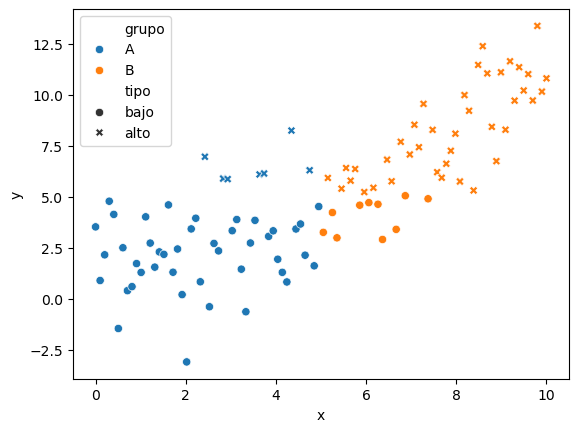

In [3]:
df["tipo"] = np.where(df["y"] > df["y"].mean(), "alto", "bajo")

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="grupo",
    style="tipo"
)

plt.show()

### EJERCICIO 1 — Scatter con significado 

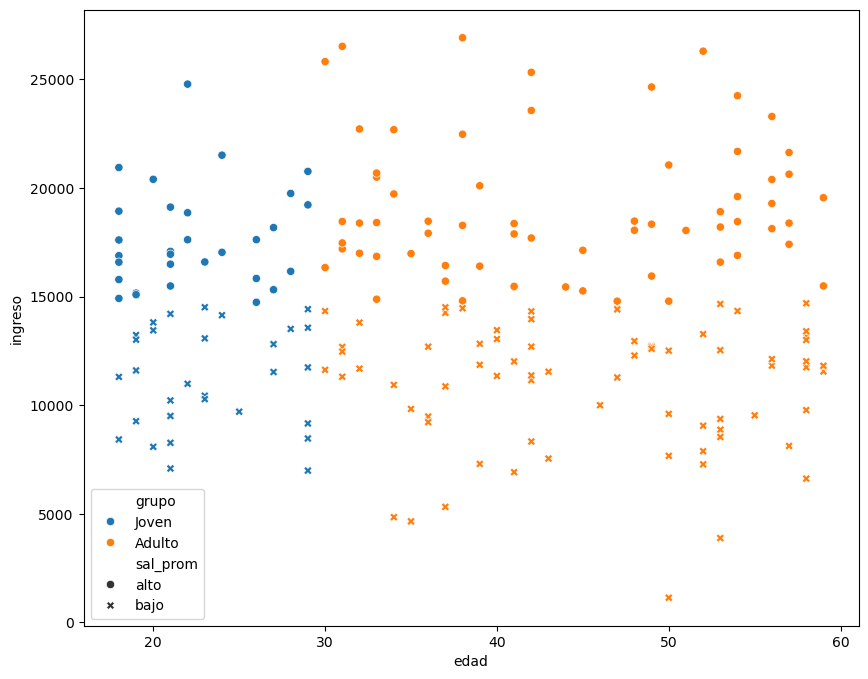

In [4]:
### Grafica un scatter y Agrega una variable categórica
np.random.seed(0)

df = pd.DataFrame({
    "edad": np.random.randint(18,60,200),
    "ingreso": np.random.normal(15000,5000,200),
})
df["grupo"] = np.where(df["edad"] < 30, "Joven", "Adulto")
df["sal_prom"] = np.where(df["ingreso"] > df["ingreso"].mean(), "alto", "bajo")

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x="edad",
    y="ingreso",
    hue="grupo",
    style="sal_prom"
)
plt.show()

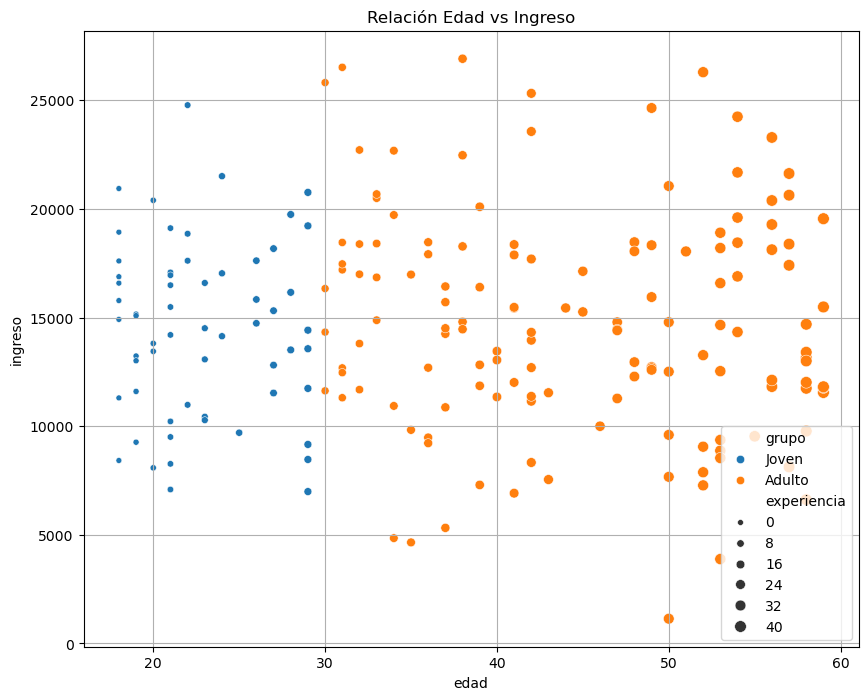

In [5]:
### Haz un scatter con: hue="grupo" y size="experiencia"
df["experiencia"] = df["edad"] - 18

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x="edad",
    y="ingreso",
    hue="grupo",
    size="experiencia"
)
plt.title("Relación Edad vs Ingreso")
plt.grid(True)
plt.show()


## Distribuciones con Seaborn

* Una histrograma basico: “muéstrame cómo se distribuyen los valores de ingreso”.
* Más bins ≠ más suavidad , Más datos = más suavidad.
* `KDE` más suave: ***quitar ruido visual del histograma***.
* `Histograma` = depende de `bins`.
* `KDE` = estimación continua.

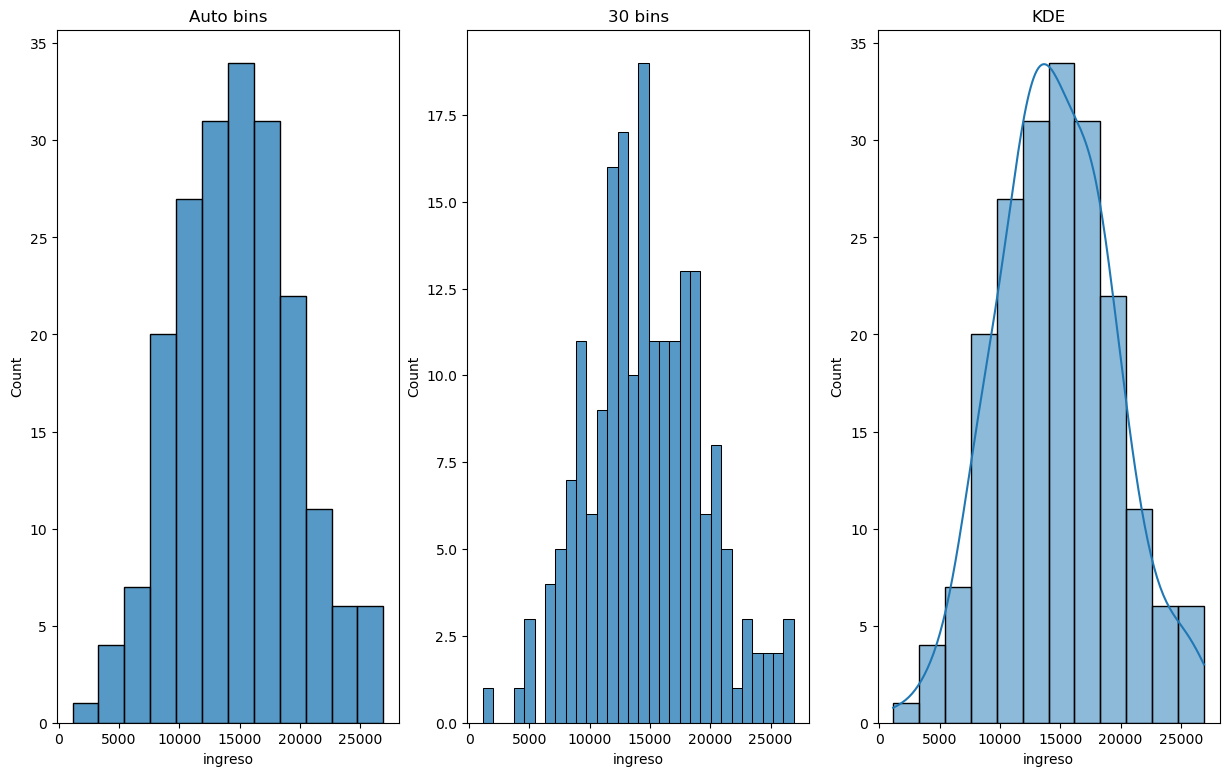

In [21]:
fig, axes = plt.subplots(1,3, figsize=(15,9))

sns.histplot(data=df, x="ingreso", ax=axes[0])
axes[0].set_title("Auto bins")

sns.histplot(data=df, x="ingreso", bins=30, ax=axes[1])
axes[1].set_title("30 bins")

sns.histplot(data=df, x="ingreso", kde=True, ax=axes[2])
axes[2].set_title("KDE")

plt.show()

### Hue

* distribución de ingresos separada por grupo.
* `col="grupo"`: interesante para separar por columna, en varios histogramas.

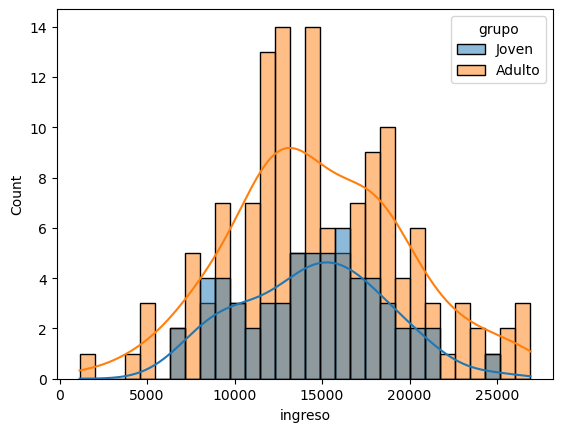

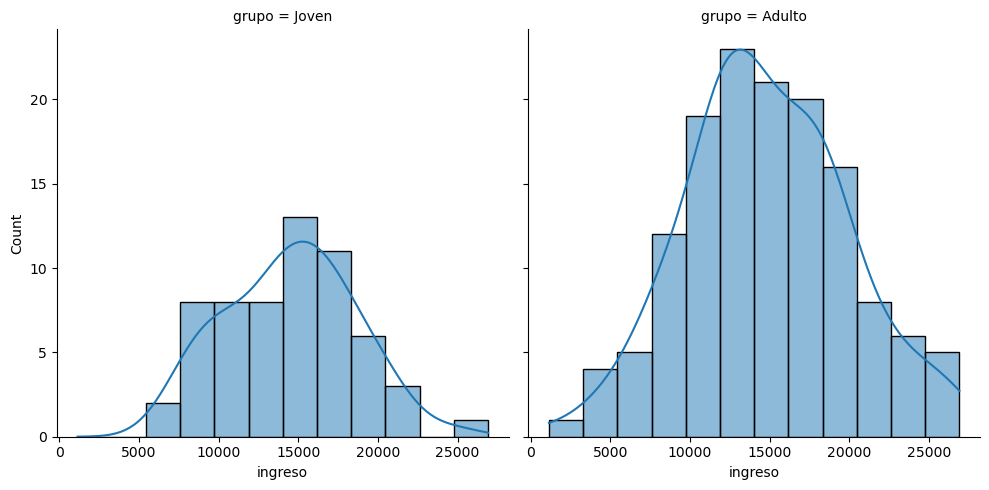

In [27]:
sns.histplot(data=df, x="ingreso", hue="grupo", bins=30, kde=True)
sns.displot(data=df, x="ingreso", col="grupo", kde=True)
plt.show()

## EJERCICIO

### Datos a Visualizar

***DATASET DE PINGÜINOS***
* Dentro de este dataset encontraremos las siguientes caracteristicas:
  - Longitud del pico.
  - Profundidad del pico.
  - Longitud de la aleta.
  - Masa Corporal.
  - Especie.
  - Isla.
  - Sexo.
* Este lo sacaremos de `sns`.
***Notas***
* `sns.get_dataset_names()`: toda las plantillas de datos pregargadas de la librería.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Esto ya nos regresa un dataframe
pinguinos = sns.load_dataset("penguins")
print("\nColumnas Originales:\n", pinguinos.columns)
pinguinos.columns = [
    "especie",
    "isla",
    "longitud_pico",
    "profundidad_pico",
    "longitud_aleta",
    "masa",
    "sexo"
]
print("\nDataset Final:\n", pinguinos)


Columnas Originales:
 Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

Dataset Final:
     especie       isla  longitud_pico  profundidad_pico  longitud_aleta  \
0    Adelie  Torgersen           39.1              18.7           181.0   
1    Adelie  Torgersen           39.5              17.4           186.0   
2    Adelie  Torgersen           40.3              18.0           195.0   
3    Adelie  Torgersen            NaN               NaN             NaN   
4    Adelie  Torgersen           36.7              19.3           193.0   
..      ...        ...            ...               ...             ...   
339  Gentoo     Biscoe            NaN               NaN             NaN   
340  Gentoo     Biscoe           46.8              14.3           215.0   
341  Gentoo     Biscoe           50.4              15.7           222.0   
342  Gentoo     Biscoe           45.2              14.8           212.0   

### Primera gráfica de Seaborn

***NOTAS***
* `style=`: `whitegrid, white, darkgrid, ticks`.
* `context`: paper (hace todo más pequeño), notebook (default), talk(más grande), poster(agrandado)
* `aspect`: Podemos reducir a la mitad o algarlo en proporción.
* `markers=["s",".","P","d"]`: cuadrados, puntos, cruces, diamentes.

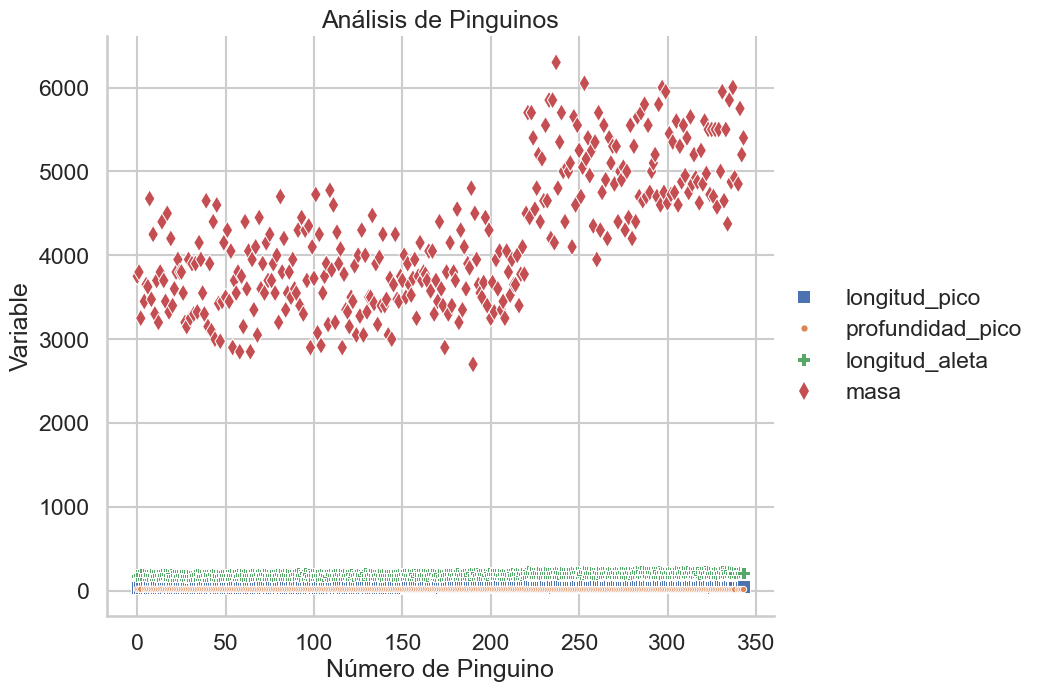

In [30]:
### Establecemos el color del fondo
sns.set_theme(style="whitegrid", context="talk")

### Cargamos los datos sin espeficar
relational = sns.relplot(
    data=pinguinos,
    height=7,
    aspect=1.2,
    markers=["s",".","P","d"])
relational.set(title="Análisis de Pinguinos")
relational.set_ylabels("Variable")
relational.set_xlabels("Número de Pinguino")
plt.show()

### Diagramas de Dispersión

***NOTAS***
* A mayor longuitud de pico y aleta, más masa tendrá el pinguino.
* La especie G es la que tiene más grande las aletas y pico.
* `relplot, catplot, displot` → figure-level (NO usan ax).
* `scatterplot, lineplot, histplot` → axes-level (SÍ usan ax).
* `scatterplot` → nivel axes (bajo nivel)
* Es una función “simple” que dibuja un solo gráfico en un eje.
  - Va dentro de matplotlib (`plt.subplots`)
  - `Usa ax=`.
  - Máximo control manual del layout.
  - No crea múltiples gráficos automáticamente.
* `relplot` → nivel figure (alto nivel)
* Es un ***wrapper*** que puede crear varios gráficos automáticamente.
* Internamente usa `scatterplot` o `lineplot`, pero añade facetas.
  - Crea su propia figura.
  - Permite dividir datos en múltiples gráficos
  - Usa: `row=, col=, kind="scatter" o "line"`.
* `scatterplot` = construir a mano , `relplot` = plantilla automática.

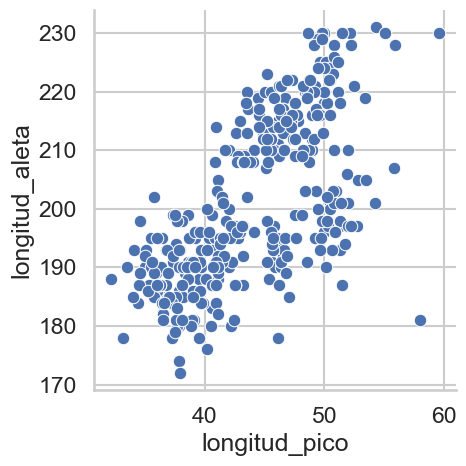

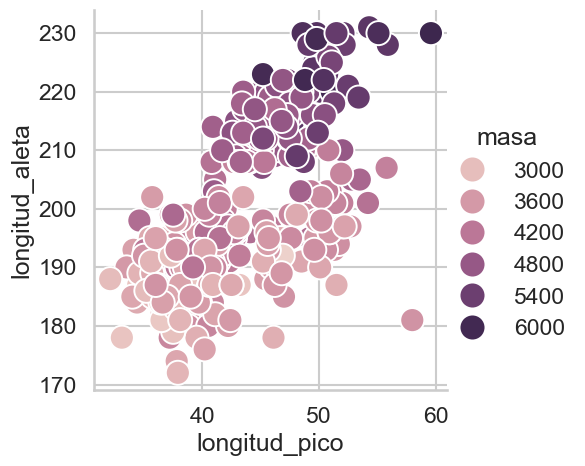

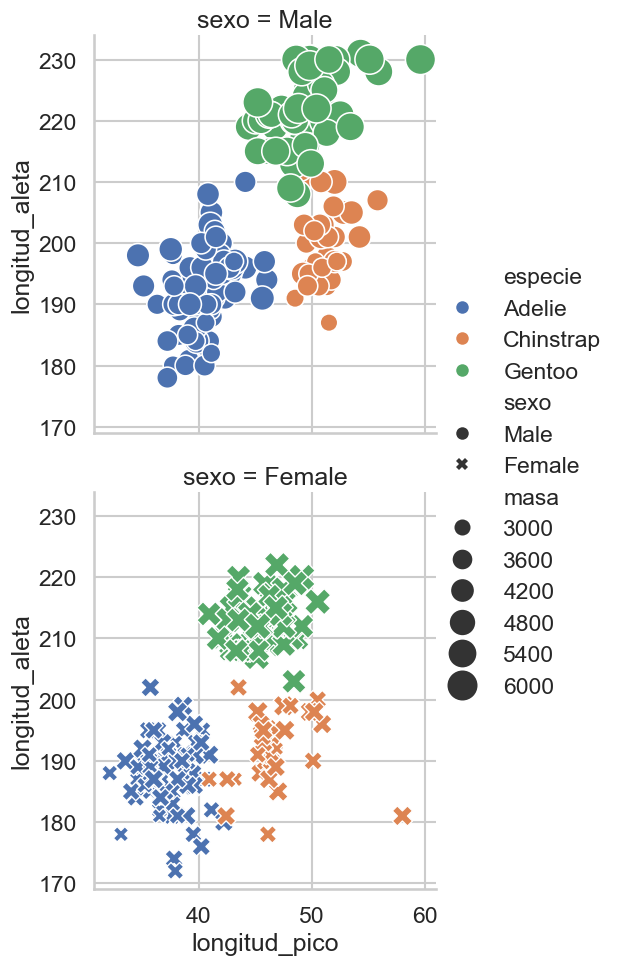

In [34]:
### Gráfica Normal, pero no nos da mucha información
sns.relplot(
    data=pinguinos,
    x="longitud_pico",
    y="longitud_aleta"
)

### Gráfica en base a la masa
sns.relplot(
    data=pinguinos,
    x="longitud_pico",
    y="longitud_aleta",
    hue="masa",
    s=300
)

### Gráfica en base a la especie, separando por sexo y el tamaño en base a la masa.
sns.relplot(
    data=pinguinos,
    x="longitud_pico",
    y="longitud_aleta",
    hue="especie",
    row="sexo",
    size="masa",
    sizes=(100,500),
    style="sexo"
)
plt.show()

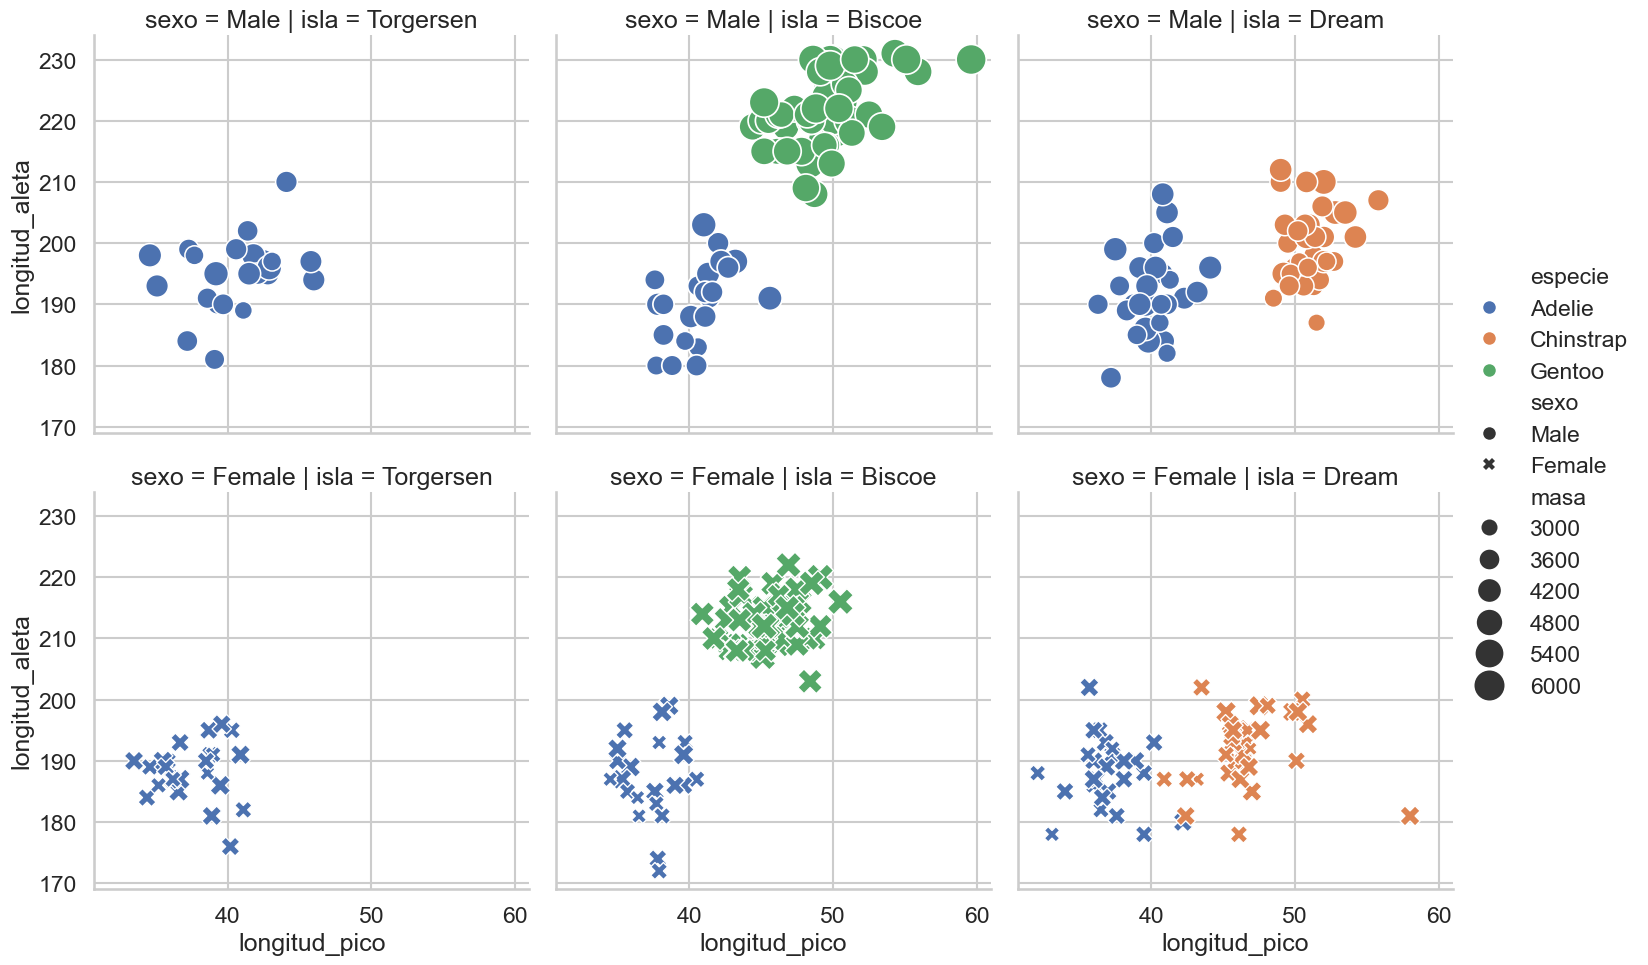

In [36]:
### Separar ahora también por isla.
sns.relplot(
    data=pinguinos,
    x="longitud_pico",
    y="longitud_aleta",
    hue="especie",
    col="isla",
    row="sexo",
    size="masa",
    sizes=(100,500),
    style="sexo"
)

### Gráficos de Líneas

* Por default para las relaciones es la de disperción.
* En este ocasión estamos separando por sexo.
* Agregamos que el estilo de la linea (su forma no color), dependa del sexo.

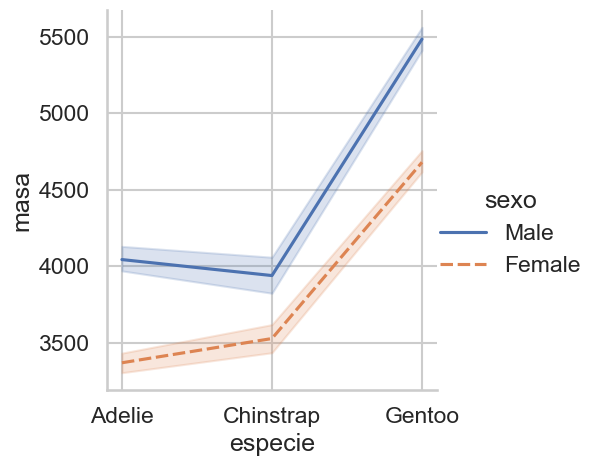

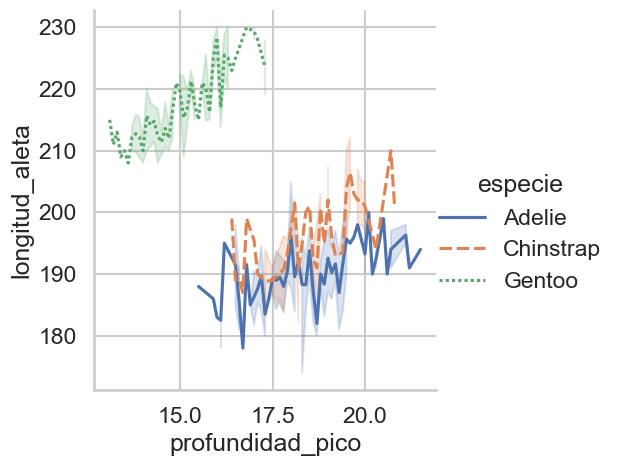

In [37]:
sns.relplot(
    data=pinguinos,
    x="especie",
    y="masa",
    kind="line",
    hue="sexo",
    style="sexo"
)
plt.show()

sns.relplot(
    data=pinguinos,
    x="profundidad_pico",
    y="longitud_aleta",
    kind="line",
    hue="especie",
    style="especie"
)
plt.show()

### Combinando Gráficas

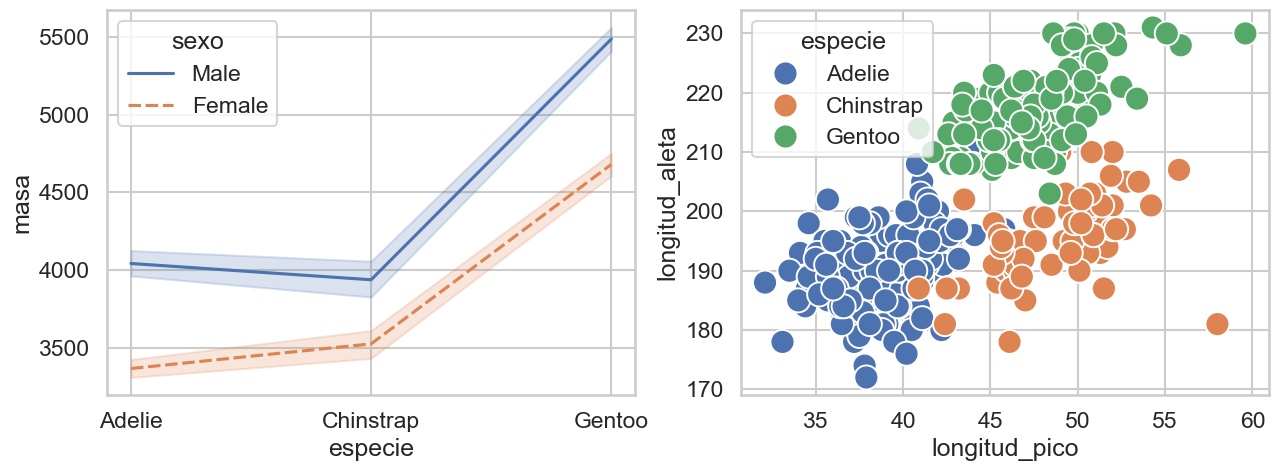

In [38]:

### Si no especificamos esto saldrían amontonadas
# En un renglón mete 2 figuras.
figura, ejes = plt.subplots(1,2, figsize=(15,5))

sns.lineplot(
    data=pinguinos,
    x="especie",
    y="masa",
    hue="sexo",
    style="sexo",
    ax=ejes[0]
)

sns.scatterplot(
    data=pinguinos,
    x="longitud_pico",
    y="longitud_aleta",
    hue="especie",
    s=300,
    ax=ejes[1]
)

plt.show()